In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('dataset.csv')


In [3]:
df.head()

,key_feature,Data
0,37.454012,113.232506
1,95.071431,282.224218
2,73.199394,220.515790
3,59.865848,159.721856
4,15.601864,44.608873


In [4]:
df.isnull().sum()

,0
key_feature,0
Data,0


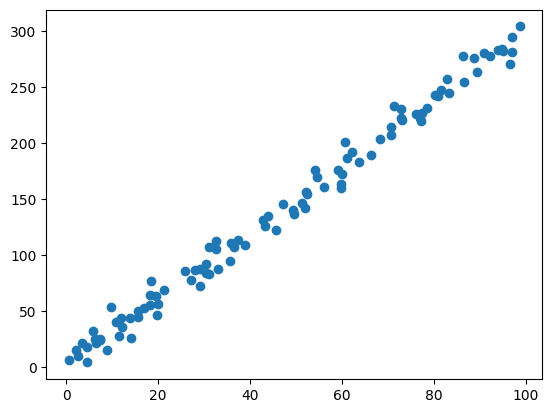

In [5]:
plt.scatter(df['key_feature'],df['Data'])

In [6]:
df.corr()

,key_feature,Data
key_feature,1.000000,0.994766
Data,0.994766,1.000000


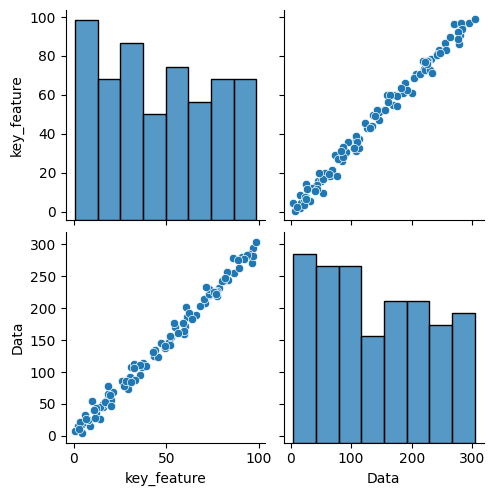

In [7]:
sns.pairplot(df)

In [8]:
x = df[['key_feature']]
y = df['Data']


In [10]:
x.shape
y.shape

(100,)

In [12]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.3 , random_state = 42)

In [14]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(70, 1)
(30, 1)
(70,)
(30,)


In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [17]:
x_train

array([[ 1.80128424],
       [ 0.18151327],
       [-0.52021911],
       [ 0.44201558],
       [ 0.32989749],
       [-1.12942681],
       [-1.18369128],
       [ 0.26299142],
       [ 1.21971702],
       [-0.59562284],
       [-1.02550921],
       [ 1.78588086],
       [ 1.42776441],
       [ 0.08691266],
       [ 0.16050796],
       [-0.64247986],
       [ 0.55321976],
       [ 1.13610245],
       [ 1.29295699],
       [-0.92654366],
       [-0.04892809],
       [ 0.4644984 ],
       [ 0.1983951 ],
       [ 0.77263151],
       [ 0.47334376],
       [-0.40037726],
       [-1.48198017],
       [-0.67954831],
       [-0.59428506],
       [ 0.00920592],
       [-1.37248516],
       [-1.30263435],
       [ 0.46176721],
       [ 1.58311638],
       [ 1.80011319],
       [ 1.197391  ],
       [-0.56872939],
       [-1.4226864 ],
       [-0.71406329],
       [-0.15165395],
       [-1.27390884],
       [ 0.09188644],
       [-1.52827266],
       [ 0.27744556],
       [-1.59959703],
       [-0

In [18]:
x_test

array([[-1.46226697],
       [ 1.53093042],
       [ 1.08954038],
       [ 0.69445641],
       [-0.75932138],
       [-0.1062431 ],
       [-0.63918333],
       [ 1.41670029],
       [-1.61700537],
       [-0.34249729],
       [-0.13579622],
       [ 0.49649605],
       [ 1.24515305],
       [ 1.7255808 ],
       [-1.26049535],
       [-1.12933996],
       [ 1.08603172],
       [-1.42450835],
       [ 1.30629827],
       [-1.07710925],
       [ 1.62831967],
       [ 1.50351207],
       [-0.97214842],
       [-1.56730043],
       [ 1.86241459],
       [-1.03073011],
       [-1.25169514],
       [ 0.1911086 ],
       [ 0.85847193],
       [-1.67124132]])

In [19]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [21]:
lr.coef_

array([82.01992445])

In [22]:
lr.intercept_

139.8849605035857

In [24]:
lr.predict(x_test)

array([ 19.94993409, 265.45175822, 229.24897998, 196.84422269,
        77.60547831, 131.17090967,  87.45919183, 256.08261137,
         7.25830233, 111.79335834, 128.74696495, 180.6075292 ,
       242.01231973, 281.41696743,  36.4992275 ,  47.25658197,
       228.96120006,  23.04689323, 247.02744551,  51.54054133,
       273.43961715, 263.20290724,  60.14942044,  11.33509789,
       292.6400647 ,  55.3445546 ,  37.22102001, 155.55967318,
       210.29676347,   2.8098734 ])

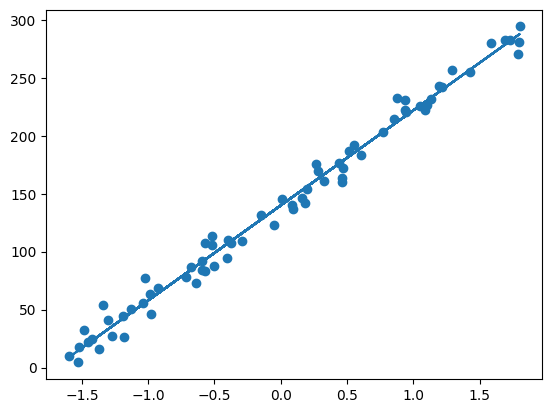

In [26]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train))

In [27]:
y_pred = lr.predict(x_test)

In [28]:
print(y_pred)

[ 19.94993409 265.45175822 229.24897998 196.84422269  77.60547831
 131.17090967  87.45919183 256.08261137   7.25830233 111.79335834
 128.74696495 180.6075292  242.01231973 281.41696743  36.4992275
  47.25658197 228.96120006  23.04689323 247.02744551  51.54054133
 273.43961715 263.20290724  60.14942044  11.33509789 292.6400647
  55.3445546   37.22102001 155.55967318 210.29676347   2.8098734 ]


In [30]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(mae)
print(mse)
print(rmse)

5.97339551854692
63.094956235044506
7.943233361487279


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   key_feature  100 non-null    float64
 1   Data         100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [33]:

import statsmodels.api as sm
model = sm.OLS(y_train,x_train).fit()
prediction = model.predict(x_test)
print(prediction)

[-119.93502642  125.56679772   89.36401948   56.95926219  -62.27948219
   -8.71405083  -52.42576867  116.19765087 -132.62665817  -28.09160217
  -11.13799556   40.7225687   102.12735922  141.53200692 -103.385733
  -92.62837853   89.07623956 -116.83806727  107.14248501  -88.34441918
  133.55465665  123.31794674  -79.73554006 -128.54986261  152.7551042
  -84.54040591 -102.6639405    15.67471267   70.41180297 -137.0750871 ]


In [34]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   Data   R-squared (uncentered):                   0.255
Model:                            OLS   Adj. R-squared (uncentered):              0.244
Method:                 Least Squares   F-statistic:                              23.61
Date:                Sun, 19 Jan 2025   Prob (F-statistic):                    7.10e-06
Time:                        04:40:27   Log-Likelihood:                         -445.34
No. Observations:                  70   AIC:                                      892.7
Df Residuals:                      69   BIC:                                      894.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------